# Experiment 7: Bagging, Boosting, and Stacked Ensemble Models

## Section 1: Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Section 2: Load Dataset

In [15]:
data = pd.read_csv(r"C:\Users\janis\ML\breast+cancer+wisconsin+diagnostic\wdbc.data", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Section 2b: Assign Column Names & Preprocess

In [16]:
# Assign column names
columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
data.columns = columns

# Drop ID column (not useful for ML)
data.drop(columns=['id'], inplace=True)

# Encode diagnosis: M=1, B=0
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

# Features and target
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Samples        : {X.shape[0]}')
print(f'Features       : {X.shape[1]}')
print(f'Class Counts   : Benign={sum(y==0)}, Malignant={sum(y==1)}')
print(f'Missing Values : {X.isnull().sum().sum()}')
data.head()

DATASET OVERVIEW
Samples        : 569
Features       : 30
Class Counts   : Benign=357, Malignant=212
Missing Values : 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Section 3: Exploratory Data Analysis (EDA)

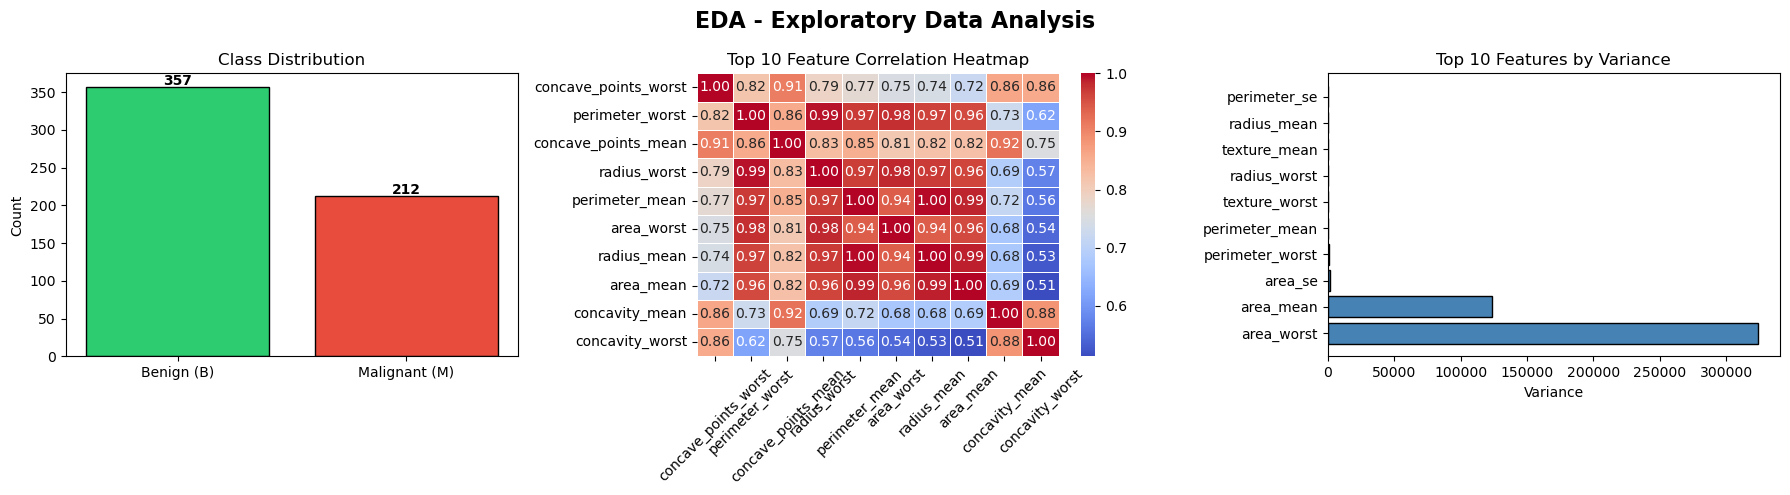

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Class distribution
axes[0].bar(['Benign (B)', 'Malignant (M)'], [sum(y==0), sum(y==1)],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([sum(y==0), sum(y==1)]):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Correlation heatmap (top 10 features)
top_feats = X.corrwith(y.astype(float)).abs().nlargest(10).index
sns.heatmap(X[top_feats].corr(), ax=axes[1], cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5)
axes[1].set_title('Top 10 Feature Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=45)

# Top features by variance
feat_var = X.var().nlargest(10)
axes[2].barh(feat_var.index, feat_var.values, color='steelblue', edgecolor='black')
axes[2].set_title('Top 10 Features by Variance')
axes[2].set_xlabel('Variance')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Train-Test Split and Scaling

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} samples | Test: {X_test_sc.shape[0]} samples')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('5-Fold Stratified CV initialized.')

Train: 455 samples | Test: 114 samples
5-Fold Stratified CV initialized.


## Section 5: Table 1 – Bagging Hyperparameter Evaluation

In [19]:
bagging_params = [
    {'n_estimators': 10,  'max_samples': 0.5},
    {'n_estimators': 10,  'max_samples': 0.8},
    {'n_estimators': 50,  'max_samples': 0.5},
    {'n_estimators': 50,  'max_samples': 0.8},
    {'n_estimators': 100, 'max_samples': 0.5},
    {'n_estimators': 100, 'max_samples': 0.8},
]

bagging_results = []
for p in bagging_params:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=p['n_estimators'],
        max_samples=p['max_samples'],
        random_state=42
    )
    scores = cross_validate(model, X_train_sc, y_train, cv=cv,
                            scoring=['accuracy', 'f1'], n_jobs=-1)
    bagging_results.append({
        'n_estimators'       : p['n_estimators'],
        'max_samples'        : p['max_samples'],
        'Avg CV Accuracy (%)': round(scores['test_accuracy'].mean() * 100, 2),
        'Avg CV F1 Score'    : round(scores['test_f1'].mean(), 4)
    })

df_bag = pd.DataFrame(bagging_results)
print('TABLE 1: BAGGING HYPERPARAMETER EVALUATION')
df_bag

TABLE 1: BAGGING HYPERPARAMETER EVALUATION


,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
0,10,0.5,94.07,0.9163
1,10,0.8,94.51,0.9226
2,50,0.5,95.82,0.9434
3,50,0.8,96.48,0.9526
4,100,0.5,95.82,0.9436
5,100,0.8,95.60,0.9399


## Section 6: Table 2 – Boosting Hyperparameter Evaluation (AdaBoost)

In [20]:
boosting_params = [
    {'n_estimators': 50,  'learning_rate': 0.01},
    {'n_estimators': 50,  'learning_rate': 0.1 },
    {'n_estimators': 50,  'learning_rate': 1.0 },
    {'n_estimators': 100, 'learning_rate': 0.01},
    {'n_estimators': 100, 'learning_rate': 0.1 },
    {'n_estimators': 100, 'learning_rate': 1.0 },
    {'n_estimators': 200, 'learning_rate': 0.1 },
    {'n_estimators': 200, 'learning_rate': 1.0 },
]

boosting_results = []
for p in boosting_params:
    model = AdaBoostClassifier(
        n_estimators=p['n_estimators'],
        learning_rate=p['learning_rate'],
        random_state=42
    )
    scores = cross_validate(model, X_train_sc, y_train, cv=cv,
                            scoring=['accuracy', 'f1'], n_jobs=-1)
    boosting_results.append({
        'n_estimators'       : p['n_estimators'],
        'learning_rate'      : p['learning_rate'],
        'Avg CV Accuracy (%)': round(scores['test_accuracy'].mean() * 100, 2),
        'Avg CV F1 Score'    : round(scores['test_f1'].mean(), 4)
    })

df_boost = pd.DataFrame(boosting_results)
print('TABLE 2: BOOSTING HYPERPARAMETER EVALUATION')
df_boost

TABLE 2: BOOSTING HYPERPARAMETER EVALUATION


,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
0,50,0.01,92.09,0.8863
1,50,0.10,95.16,0.9336
2,50,1.00,96.70,0.9546
3,100,0.01,92.53,0.8937
4,100,0.10,96.04,0.9455
5,100,1.00,96.48,0.9523
6,200,0.10,96.70,0.9542
7,200,1.00,97.14,0.9610


## Section 7: Table 3 – Stacked Ensemble Evaluation

In [21]:
stacking_configs = [
    {
        'base': 'SVM + NB + DT',
        'estimators': [
            ('svm', SVC(probability=True, random_state=42)),
            ('nb',  GaussianNB()),
            ('dt',  DecisionTreeClassifier(random_state=42))
        ],
        'final': LogisticRegression(random_state=42)
    },
    {
        'base': 'SVM + DT',
        'estimators': [
            ('svm', SVC(probability=True, random_state=42)),
            ('dt',  DecisionTreeClassifier(random_state=42))
        ],
        'final': LogisticRegression(random_state=42)
    },
    {
        'base': 'NB + DT',
        'estimators': [
            ('nb', GaussianNB()),
            ('dt', DecisionTreeClassifier(random_state=42))
        ],
        'final': LogisticRegression(random_state=42)
    },
]

stacking_results = []
for cfg in stacking_configs:
    model = StackingClassifier(
        estimators=cfg['estimators'],
        final_estimator=cfg['final'],
        cv=5
    )
    scores = cross_validate(model, X_train_sc, y_train, cv=cv,
                            scoring=['accuracy', 'f1'], n_jobs=-1)
    stacking_results.append({
        'Base Models'        : cfg['base'],
        'Meta Learner'       : 'Logistic Regression',
        'Avg CV Accuracy (%)': round(scores['test_accuracy'].mean() * 100, 2),
        'Avg CV F1 Score'    : round(scores['test_f1'].mean(), 4)
    })

df_stack = pd.DataFrame(stacking_results)
print('TABLE 3: STACKED ENSEMBLE EVALUATION')
df_stack

TABLE 3: STACKED ENSEMBLE EVALUATION


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM + NB + DT,Logistic Regression,97.36,0.9638
1,SVM + DT,Logistic Regression,97.36,0.9642
2,NB + DT,Logistic Regression,94.51,0.9244


## Section 8: Train Final Best Models

In [22]:
best_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, max_samples=0.8, random_state=42
)
best_boosting = AdaBoostClassifier(
    n_estimators=100, learning_rate=1.0, random_state=42
)
best_stacking = StackingClassifier(
    estimators=[
        ('svm', SVC(probability=True, random_state=42)),
        ('nb',  GaussianNB()),
        ('dt',  DecisionTreeClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

models = {
    'Bagging'         : best_bagging,
    'Boosting'        : best_boosting,
    'Stacked Ensemble': best_stacking
}

trained = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    trained[name] = model
    print(f'{name} trained!')

Bagging trained!
Boosting trained!
Stacked Ensemble trained!


## Section 9: Table 4 – Performance Comparison

In [23]:
comparison = []

for name, model in trained.items():
    y_pred = model.predict(X_test_sc)
    comparison.append({
        'Model'       : name,
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision'   : round(precision_score(y_test, y_pred), 4),
        'Recall'      : round(recall_score(y_test, y_pred), 4),
        'F1 Score'    : round(f1_score(y_test, y_pred), 4)
    })
    print(f'--- {name} Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

df_comp = pd.DataFrame(comparison)
print('TABLE 4: PERFORMANCE COMPARISON')
df_comp

--- Bagging Classification Report ---
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

--- Boosting Classification Report ---
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

--- Stacked Ensemble Classification Report ---
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   m

,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,97.37,1.0,0.9286,0.963
1,Boosting,97.37,1.0,0.9286,0.963
2,Stacked Ensemble,97.37,1.0,0.9286,0.963


## Section 10: Confusion Matrices

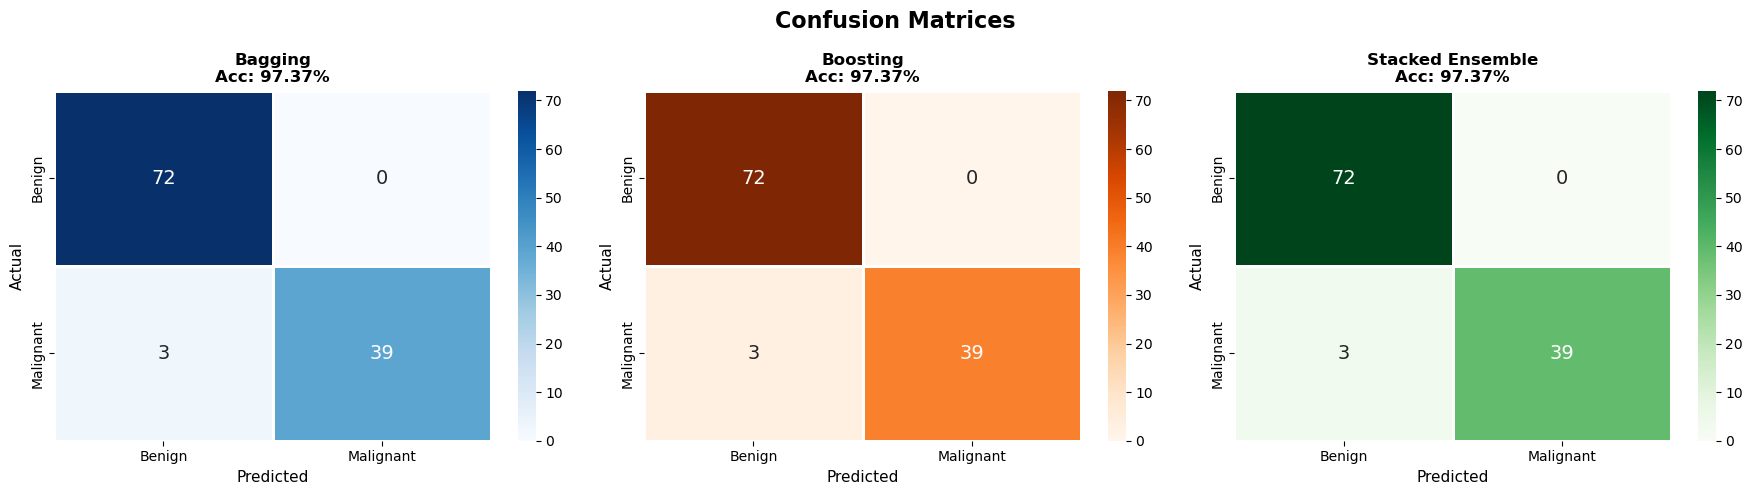

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, (name, model), cmap in zip(axes, trained.items(), ['Blues', 'Oranges', 'Greens']):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                linewidths=1, linecolor='white', annot_kws={'size': 14})
    acc = accuracy_score(y_test, y_pred) * 100
    ax.set_title(f'{name}\nAcc: {acc:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11: ROC Curves

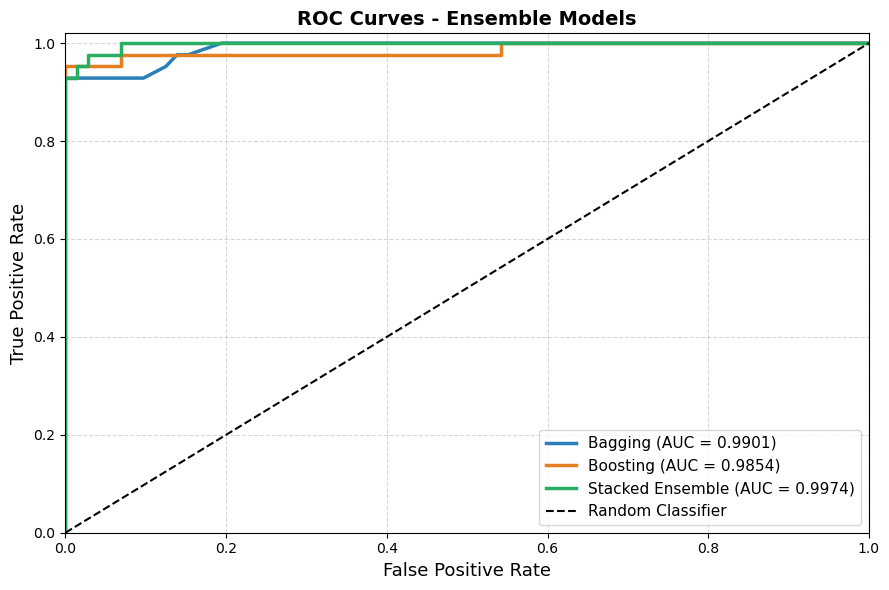

In [25]:
plt.figure(figsize=(9, 6))
colors_roc = ['#2980b9', '#e67e22', '#27ae60']

for (name, model), color in zip(trained.items(), colors_roc):
    y_score = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, lw=2.5)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - Ensemble Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12: Bar Chart – Metric Comparison

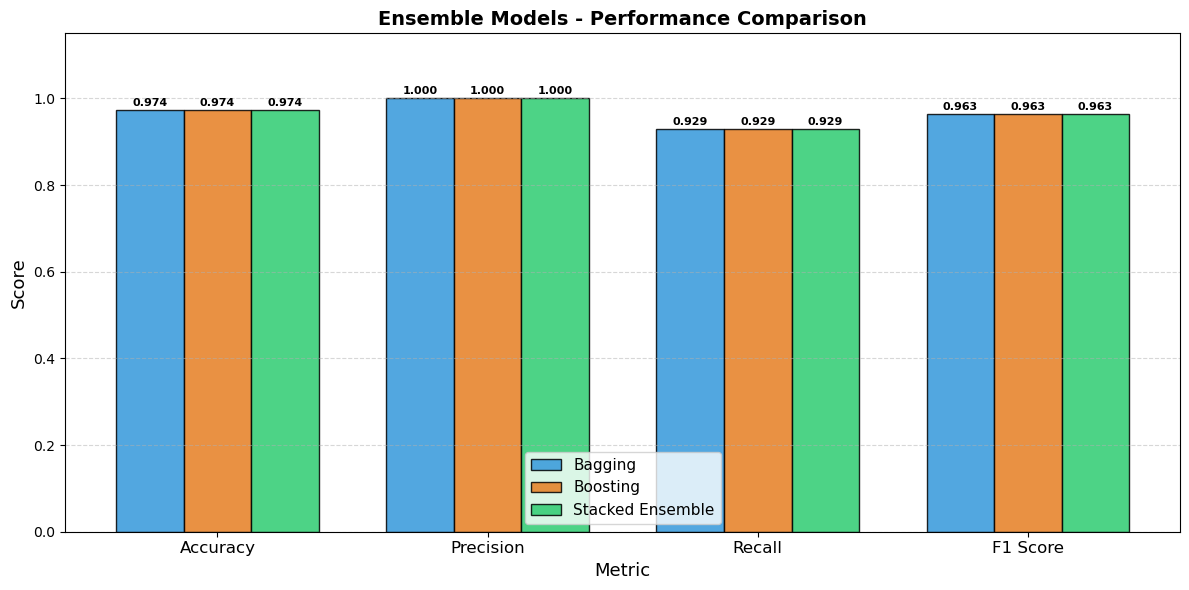

In [26]:
x = np.arange(4)
width = 0.25
bar_colors = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 6))
for i, row in df_comp.iterrows():
    vals = [row['Accuracy (%)']/100, row['Precision'], row['Recall'], row['F1 Score']]
    bars = ax.bar(x + i * width, vals, width, label=row['Model'],
                  color=bar_colors[i], edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Ensemble Models - Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'], fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()